In [1]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()
data_num = torchvision.datasets.MNIST(
    root='./data_num',
    train=True,
    download=True,
    transform = transform
)

data_loader = DataLoader(
    data_num,
    batch_size=64,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:16<00:00, 619kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 944kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.16MB/s]


In [3]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size = 3, stride = 2, padding = 1),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size = 3, stride = 2, padding = 1),
            nn.ReLU(),

            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 24)
        )

        self.decoder = nn.Sequential(
            nn.Linear(24, 32 * 7 * 7),
            nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 3, stride = 2, padding = 1, output_padding = 1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride = 2, padding = 1, output_padding = 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
    


In [4]:
criterion = nn.MSELoss()
model = AutoEncoder()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    losss = 0
    for x, _ in data_loader:
        x_hat = model(x)
        loss = criterion(x_hat, x)
        optimizer.zero_grad()
        loss.backward()
        losss += loss.item()
        optimizer.step()
    print(f'Epoch [{epoch+1}/10], Loss: {losss/len(data_loader):.4f}')

Epoch [1/10], Loss: 0.0311
Epoch [2/10], Loss: 0.0110


KeyboardInterrupt: 

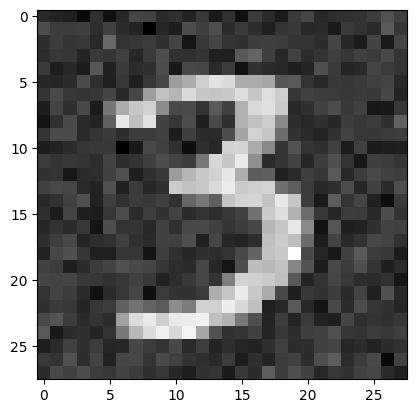

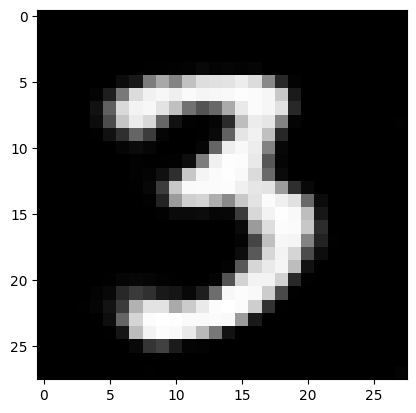

In [5]:
x = data_num[10000][0]
x_bruit = x + 0.1 * torch.randn_like(x)
plt.imshow(x_bruit.squeeze(), cmap='gray')
plt.show()

y = x_bruit.unsqueeze(0)


with torch.no_grad():
    y_hat = model(y)
    y_hat = y_hat.squeeze()
    y_hat = y_hat.squeeze()

plt.imshow(y_hat, cmap='gray')

plt.show()


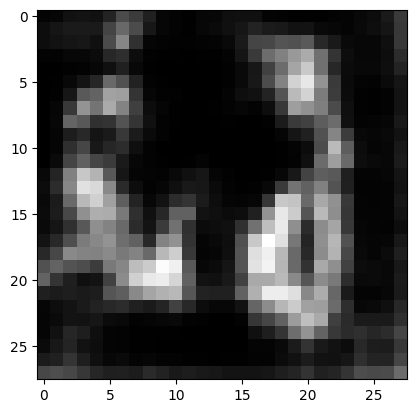

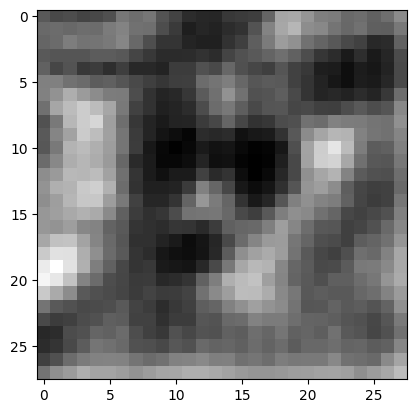

In [6]:
#tentative de générer des images aléatoires
#image aléatoire dans l'espace latent -> décodeur -> autoencodeur pour enlever le bruit -> image finale
#rien de concluant

x_rand = torch.randn(1, 24)
with torch.no_grad():
    x_rand_hat = model.decoder(x_rand)
    x_rand_hat = x_rand_hat.squeeze()
    x2_rand_hat = x_rand_hat.unsqueeze(0)
    x2_rand_hat = x2_rand_hat.unsqueeze(0)
    x2_rand_hat = model(x2_rand_hat)

plt.imshow(x2_rand_hat.squeeze(), cmap='gray')
plt.show()
plt.imshow(x_rand_hat, cmap='gray')